In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
# Upload the dataset
df = pd.read_csv('AB_NYC_2019.csv')

# General Information about the dataset
print(f"Dataset Size: {df.shape}")
print(f"• Total Number of Rows: {df.shape[0]}")
print(f"• Total Number of Columns: {df.shape[1]}")
print("-" * 30)
print("Data Types and Missing Values:")
print(df.info())

Dataset Size: (48895, 16)
• Total Number of Rows: 48895
• Total Number of Columns: 16
------------------------------
Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimu

In [ ]:
stats = df[['price', 'minimum_nights', 'number_of_reviews']].describe()
print("Basic Statistics:")
display(stats)

# Variance and Covariance
print(f"\nPrice Variance: {df['price'].var()}")
print(f"Price and Number of Reviews Covariance: {df['price'].cov(df['number_of_reviews'])}")

# Correlation Analysis
correlation = df.select_dtypes(include=[np.number]).corr()
print("\nCorrelation Matrix:")
display(correlation)

Basic Statistics:


,price,minimum_nights,number_of_reviews
count,48895.000000,48895.000000,48895.000000
mean,152.720687,7.029962,23.274466
std,240.154170,20.510550,44.550582
min,0.000000,1.000000,0.000000
25%,69.000000,1.000000,1.000000
50%,106.000000,3.000000,5.000000
75%,175.000000,5.000000,24.000000
max,10000.000000,1250.000000,629.000000



Price Variance: 57674.02524696099
Price and Number of Reviews Covariance: -513.0626584457654

Correlation Matrix:


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
id,1.000000,0.588290,-0.003125,0.090908,0.010619,-0.013224,-0.319760,0.291828,0.133272,0.085468
host_id,0.588290,1.000000,0.020224,0.127055,0.015309,-0.017364,-0.140106,0.296417,0.154950,0.203492
latitude,-0.003125,0.020224,1.000000,0.084788,0.033939,0.024869,-0.015389,-0.010142,0.019517,-0.010983
longitude,0.090908,0.127055,0.084788,1.000000,-0.150019,-0.062747,0.059094,0.145948,-0.114713,0.082731
price,0.010619,0.015309,0.033939,-0.150019,1.000000,0.042799,-0.047954,-0.030608,0.057472,0.081829
minimum_nights,-0.013224,-0.017364,0.024869,-0.062747,0.042799,1.000000,-0.080116,-0.121702,0.127960,0.144303
number_of_reviews,-0.319760,-0.140106,-0.015389,0.059094,-0.047954,-0.080116,1.000000,0.549868,-0.072376,0.172028
reviews_per_month,0.291828,0.296417,-0.010142,0.145948,-0.030608,-0.121702,0.549868,1.000000,-0.009421,0.185791
calculated_host_listings_count,0.133272,0.154950,0.019517,-0.114713,0.057472,0.127960,-0.072376,-0.009421,1.000000,0.225701
availability_365,0.085468,0.203492,-0.010983,0.082731,0.081829,0.144303,0.172028,0.185791,0.225701,1.000000


In [ ]:

df['est_occupancy'] = (df['number_of_reviews'] * 2).clip(upper=365) 
df['est_annual_revenue'] = df['est_occupancy'] * df['price']


group_meds = df.groupby('neighbourhood_group')['price'].transform('median')
df['price_vs_region'] = df['price'] / group_meds

df['host_type'] = df['calculated_host_listings_count'].apply(lambda x: 'Professional' if x > 1 else 'Individual')


C:\Users\kaans\AppData\Local\Temp\ipykernel_13628\363681200.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_revenue.index, y=avg_revenue.values, palette='viridis')


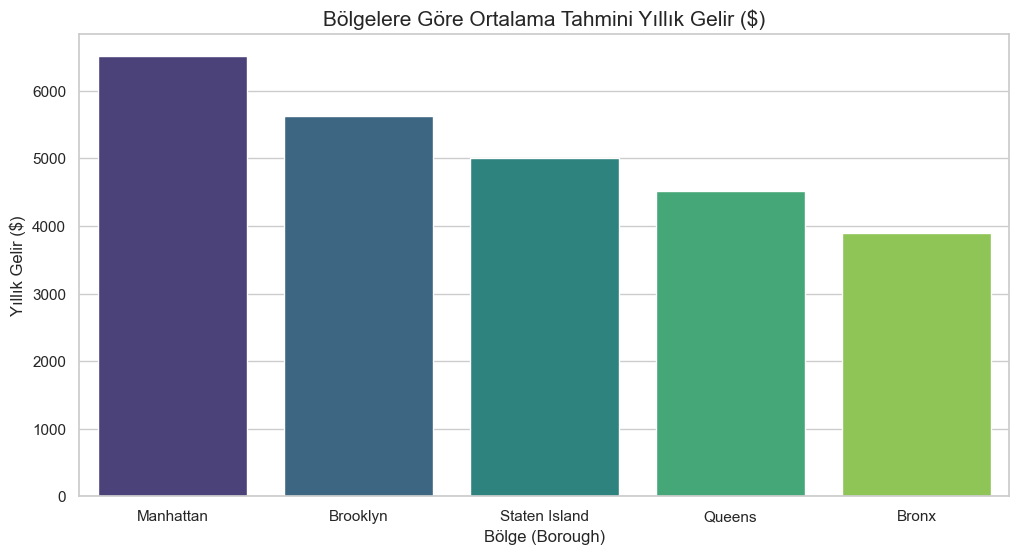

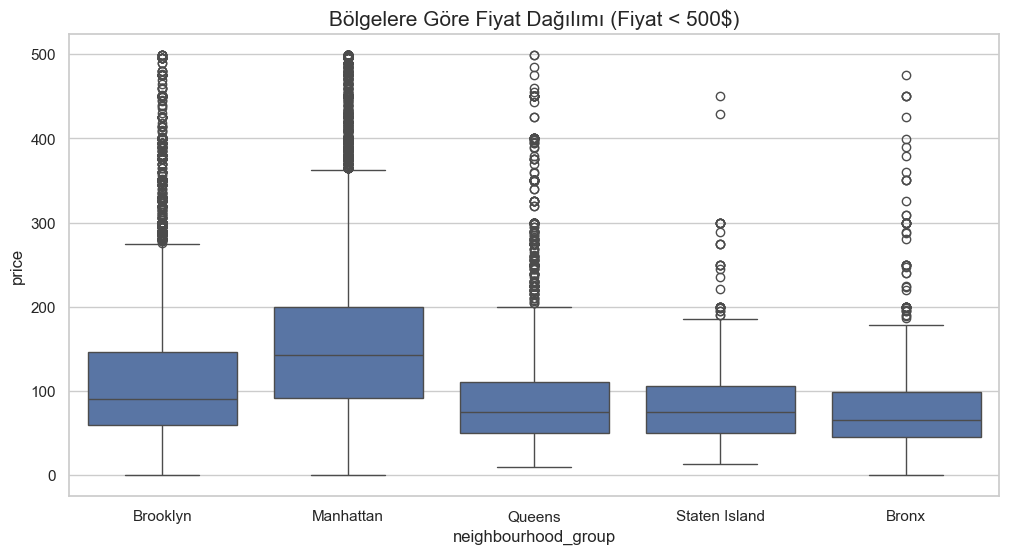

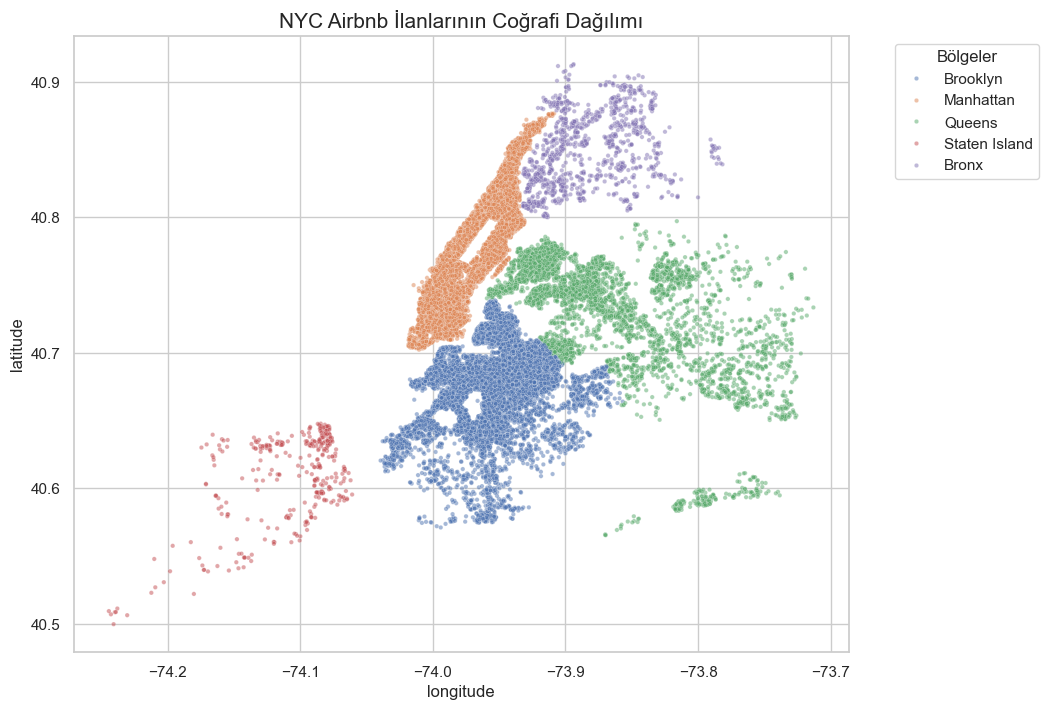

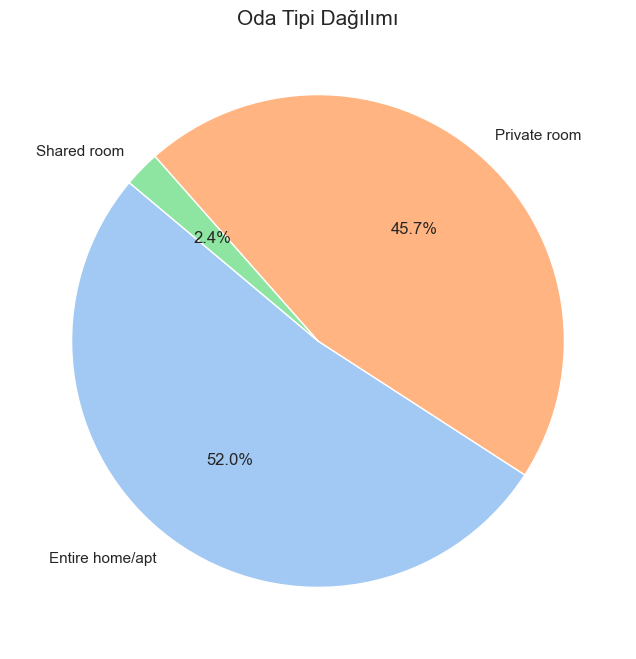

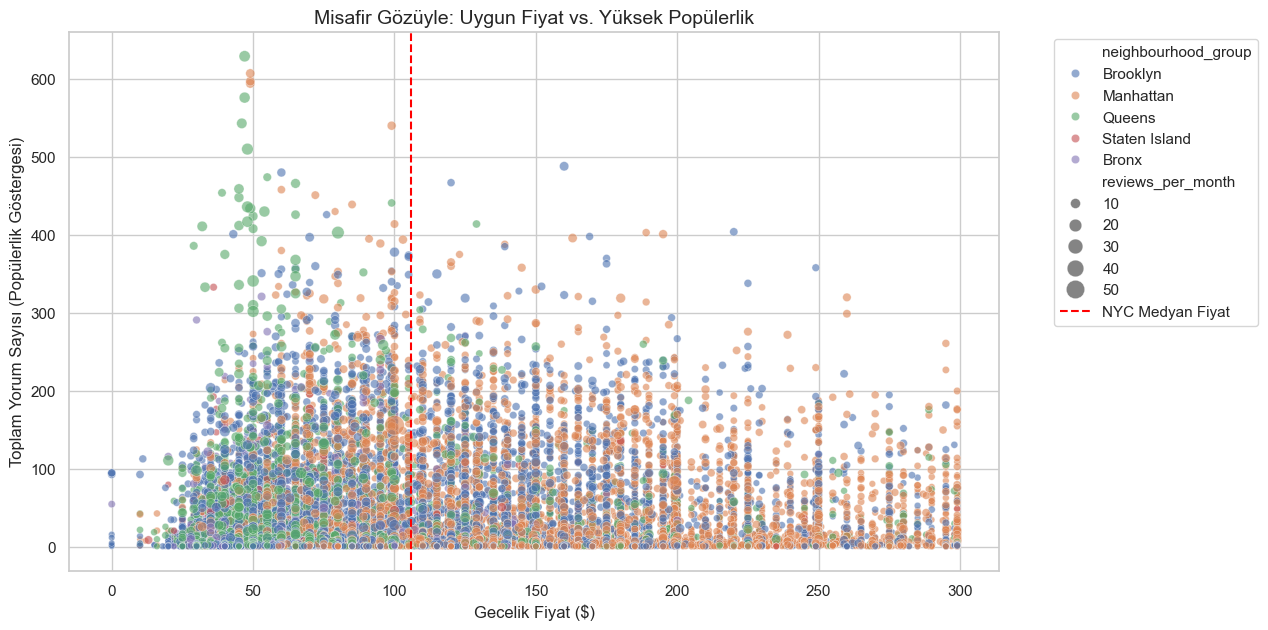

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
avg_revenue = df.groupby('neighbourhood_group')['est_annual_revenue'].mean().sort_values(ascending=False)
sns.barplot(x=avg_revenue.index, y=avg_revenue.values, palette='viridis')
plt.title('Average Estimated Annual Revenue by Borough', fontsize=15)
plt.ylabel('Yearly Revenue ($)')
plt.xlabel('Borough')
plt.show()


plt.figure(figsize=(12, 6))
sns.boxplot(x='neighbourhood_group', y='price', data=df[df.price < 500]) 
plt.title('Region-wise Price Distribution (Price < $500)', fontsize=15)
plt.show()

plt.figure(figsize=(10, 8))
sns.scatterplot(x='longitude', y='latitude', hue='neighbourhood_group', 
                data=df, s=10, alpha=0.5)
plt.title('NYC Airbnb Listings Distribution', fontsize=15)
plt.legend(title='Bölgeler', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


room_counts = df['room_type'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(room_counts, labels=room_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Room Type Distribution', fontsize=15)
plt.show()

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df[df.price < 300], x='price', y='number_of_reviews', 
                hue='neighbourhood_group', size='reviews_per_month', 
                alpha=0.6, sizes=(20, 200))

plt.title('Guest Perspective: Affordable Price vs. High Popularity', fontsize=14)
plt.xlabel('Price for per month ($)')
plt.ylabel('Total Number of Reviews (Popularity Indicator)')
plt.axvline(df['price'].median(), color='red', linestyle='--', label='NYC Median Price')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

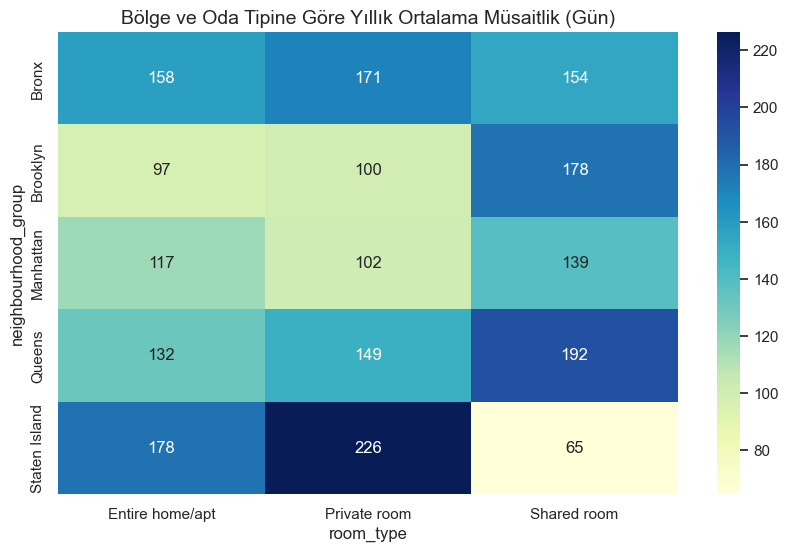

In [ ]:

pivot_table = df.pivot_table(index='neighbourhood_group', 
                             columns='room_type', 
                             values='availability_365', 
                             aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Region and Room Type-wise Yearly Average Availability (Days)', fontsize=14)
plt.show()